In [1]:
from torch.utils.data import dataset
import scipy.io as scio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import math
from sklearn.metrics import mean_squared_error
import h5py
import os
import torch
import numpy.fft as fft
import nmrglue as ng
from nmrglue.fileio.bruker import scale_pdata

import pathlib
from IPython.display import clear_output

In [2]:
import sys
!{sys.executable} -m pip install --upgrade --no-cache-dir nmrdenoise

import nmrdenoise as nd


Defaulting to user installation because normal site-packages is not writeable


Load in all functions

In [3]:
def get_snr(singal, freq1, freq2):
    """
    Calculate the signal-to-noise ratio (SNR) using Zhang's method.
    
    Parameters:
    -----------
    signal : 
        The input NMR spectrum (complex or real).
    freq1 : int
        The starting array index of the signal-free noise region.
    freq2 : int
        The ending array index of the signal-free noise region.
        
    Returns:
    --------
        The calculated SNR value
    """
    singal = np.real(singal)
    singal_max = np.max(singal)
    noise = np.real(singal[freq1:freq2])
    snr = singal_max/np.std(noise)
    return snr



def extract_noise_snippet(data, snippet_size=500):
    """
    Scans the data to find the baseline zone with minimal peaks 
    """
    real_data = np.real(data)
    N = len(real_data)
    
    indices = range(0, N - snippet_size, 20)

    # chops the data up into snippets and goes over all snipper indices to see which has the least no. of peaks to decide on start and end index
    stds = [np.std(real_data[i : i + snippet_size]) for i in indices]
    
    # here peak with the least standard deviation is selected as if it's pure noise we shouldn't see a zone where the signal rises and falls dramatically
    best_start_idx = indices[np.argmin(stds)]
    best_end_idx = best_start_idx + snippet_size
    
    
    return best_start_idx, best_end_idx

def create_noise(data, snr):
    """
    Injects white noise to create desired snr based on zhangs peak snr calcualtion    

    Parameters:
    -----------
    data : 
        The input NMR spectrum, it has to be real part.
    snr : int
        The desired snr to create artificially

    Returns:
    --------
       The data with noise injected to meet snr criterion
    """
    # Define Target SNR in dB 
    target_snr = snr
    # find max or peak of data using same approach as Zhang
    signal_max = np.max(np.real(data))
    # follow formula from Zhang to get target snr
    target_noise_std = signal_max / target_snr
    # create this noise 
    noise = np.random.normal(0, target_noise_std, data.shape)
    # inject this noise artifically to hit approximate target snr
    # do note this will stack with existing snr from data though low
    data_with_noise = data + noise
    return data_with_noise


def normalize_data(data, og_data):
    """
    normalizes data based on max and min of the og data
    """
    raw_real = np.real(data)
    scaling_factor = np.max(og_data)
    normalized_data = raw_real / scaling_factor

    return normalized_data
    
def testing_snr(nmr_file, snr):
    """
    Computes denoised across all models (ML and non-ML), and calculated snr

    Parameters:
    -----------
    nmr_file : 
        The input NMR file path
    snr : int
        The desired snr to create artificially

    Returns:
    --------
       All data; original data, noisy data and denoised data
    """

    dic, fid = ng.bruker.read(nmr_file)
    fid = ng.bruker.remove_digital_filter(dic, fid)
    data = ng.process.proc_base.fft(fid)
    data = ng.process.proc_autophase.autops(data, 'acme')  # 'acme' for auto phasing
    data = scale_pdata(dic, data) * 2

    T = np.size(data)  # total duration in seconds
    time = np.linspace(0, T, num=np.size(data))

    ## add noise
    noisy_data = create_noise(data, snr)

    multiple = 2**7  # 128
    new_length = (len(noisy_data) // multiple) * multiple

    cropped_data = noisy_data[:new_length]

    # LD net requires data normalization  as it's not in-built 
    data_min = cropped_data.min()
    data_max = cropped_data.max()
    normalized_data = (cropped_data - data_min) / (data_max - data_min)
    fn= len(normalized_data)
    cropped_data_reform = normalized_data.reshape(1, fn)

    # test snr across the models
    dn = nd.Desperate()
    specrecon, coeffin, coeffs = dn.wavelet_denoise(7, cropped_data, 0, wave = 'bior2.2', threshold = 'mod', alpha = 0)

    ld_system = nd.LD_net()
    output_ld = ld_system.test(cropped_data_reform, fn)

    output_ld = output_ld*(data_max - data_min) + data_min


    ae = nd.AE_denoise()
    autoencoder_path = ae.load_denoising_checkpoint(model_name="autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt")
    ae_denoised_data, confidence = ae.denoise_component(cropped_data, autoencoder_path)

    return data, noisy_data, specrecon, output_ld, ae_denoised_data

Run Tests

Optimization terminated successfully.
         Current function value: 38340026.061790
         Iterations: 112
         Function evaluations: 216
Loading checkpoint from: /home/kinkini/.local/lib/python3.11/site-packages/nmrdenoise/checkpoints/autoencoder_20000_bruker_ver_135_percent_noise_with_noshuffle_v4_rm_spikelets_with_lb_5.pt
Autoencoder model loaded successfully.


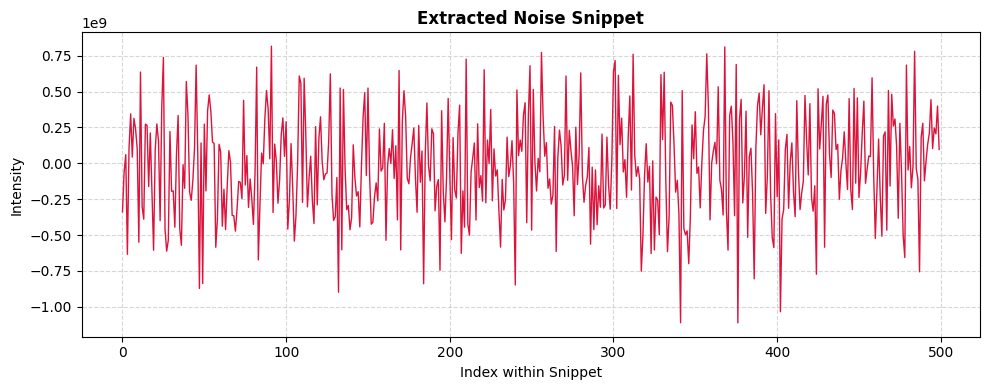

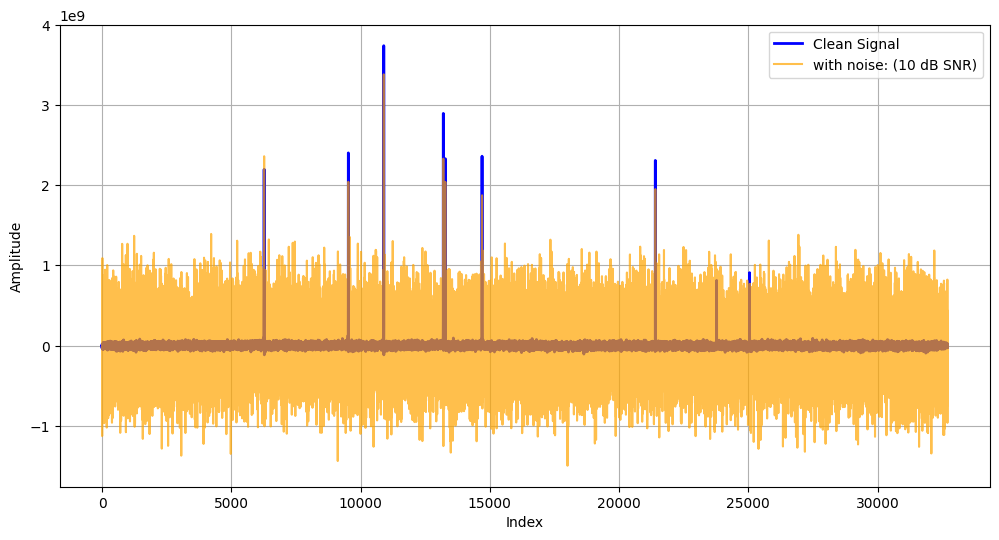

snr of AE 183.01443770833674
snr of AE [ 2.33583284e+08-4101417.76486803j -4.59597403e+08 -116676.87010777j
  5.32652082e+07+7000572.38843494j ... -3.84347862e+08-9382160.37532992j
 -4.36986755e+08+9609630.37083411j  2.83842711e+08-4321818.52236011j]
snr of desperate 357.4762740875303
snr of LD 15.793375968933105
snr of AE 895.8285522460938


In [4]:
all_snr_data = []
# can set max to a 1000
max_file_count = 25

# please download the required dataset from https://np-mrd.org/downloads >> Backfilled Spectra, NMR Spectra FID Files
data_dir = pathlib.Path("/home/kinkini/Downloads/Chemistry/NMR/benchmark_all_data/")

for file_path in data_dir.rglob("fid"):
    parent_folder = str(file_path.parent)

    if max_file_count <= 0:
        break
    
    max_file_count -= 1

    for snr in (50, 30, 20, 10):

        try:
            
            current_folder_record = {
                "folder_id": parent_folder
                                    }
                                    
            # feel free to use this function to plot individial spectra: specrecon, output_ld, ae_denoised_data on desired parents folder
            data, noisy_data, denoised_desperate, denoised_ld, denoised_ae = testing_snr(parent_folder, snr)

            best_start_idx, best_end_idx = extract_noise_snippet(data)


            plt.figure(figsize=(10, 4))
            plt.plot(noisy_data[best_start_idx:best_end_idx], color='crimson', linewidth=1)

            plt.title("Extracted Noise Snippet", fontsize=12, fontweight='bold')
            plt.xlabel("Index within Snippet", fontsize=10)
            plt.ylabel("Intensity", fontsize=10)
            plt.grid(True, linestyle='--', alpha=0.5)

            plt.tight_layout()
            plt.show()


            plt.figure(figsize=(12, 6))
            plt.plot(data, label="Clean Signal", color="blue", linewidth=2)
            plt.plot(noisy_data, label=f"with noise: ({snr} dB SNR)", color="orange", alpha=0.7)
            # convert to ppm later, rn just shows the index
            plt.xlabel('Index')
            plt.ylabel('Amplitude')
            plt.legend()
            plt.grid(True)
            plt.show()

            # see starting snr (should be high)
            snr_data = get_snr(data, best_start_idx, best_end_idx)
            print(f'snr of AE {snr_data}')

            ## get snr of noisy data, will roughly match with set snr
            snr_noisy_data = get_snr(noisy_data, best_start_idx, best_end_idx)
            print(f'snr of AE {noisy_data}')

            snr_desperate = get_snr(denoised_desperate, best_start_idx, best_end_idx)
            print(f'snr of desperate {snr_desperate}')

            snr_ld = get_snr(denoised_ld, best_start_idx, best_end_idx)
            print(f'snr of LD {snr_ld}')

            snr_ae = get_snr(denoised_ae, best_start_idx, best_end_idx)
            print(f'snr of AE {snr_ae}')

            current_folder_record[snr] = {
                            "snr_desperate": snr_desperate,
                            "snr_ld": snr_ld,
                            "snr_ae": snr_ae,
                            "snr_noisy": snr_noisy_data,
                            "og_data": data,
                            "noisy": noisy_data,
                            "desperate": denoised_desperate,
                            "ld": denoised_ld,
                            "ae": denoised_ae
                        }

            all_snr_data.append(current_folder_record)
            
            # ensure that you clear output so that you don't overconsume meomory
            clear_output(wait=True)
        except Exception as e:
            print(f"Error processing {parent_folder}: {e}")
            continue


View the last data file
need to normalize all the data to 0 to 1 so can view along with LD net 

lower snr means there is more noise present, so we geenrally want to aim for higher snr
Swap set_snr to anything from 10, 7, 5, 2, and see what changes. record these values onto a table

Select a desired SNR

In [5]:
set_snr = 50

In [6]:
all_snr_desperate = [item[set_snr]['snr_desperate'] for item in all_snr_data if set_snr in item]
all_snr_ld = [item[set_snr]['snr_ld'] for item in all_snr_data if set_snr in item]
all_snr_ae = [item[set_snr]['snr_ae'] for item in all_snr_data if set_snr in item]
all_snr_noisy = [item[set_snr]['snr_noisy'] for item in all_snr_data if set_snr in item]


In [7]:
all_desperate = [item[set_snr]['desperate'] for item in all_snr_data if set_snr in item]
all_ld = [item[set_snr]['ld'] for item in all_snr_data if set_snr in item]
all_ae = [item[set_snr]['ae'] for item in all_snr_data if set_snr in item]
all_noisy = [item[set_snr]['noisy'] for item in all_snr_data if set_snr in item]
all_og_data = [item[set_snr]['og_data'] for item in all_snr_data if set_snr in item]

Select a desired index to view

In [8]:
set_index = 12

Compare noisy vs original data

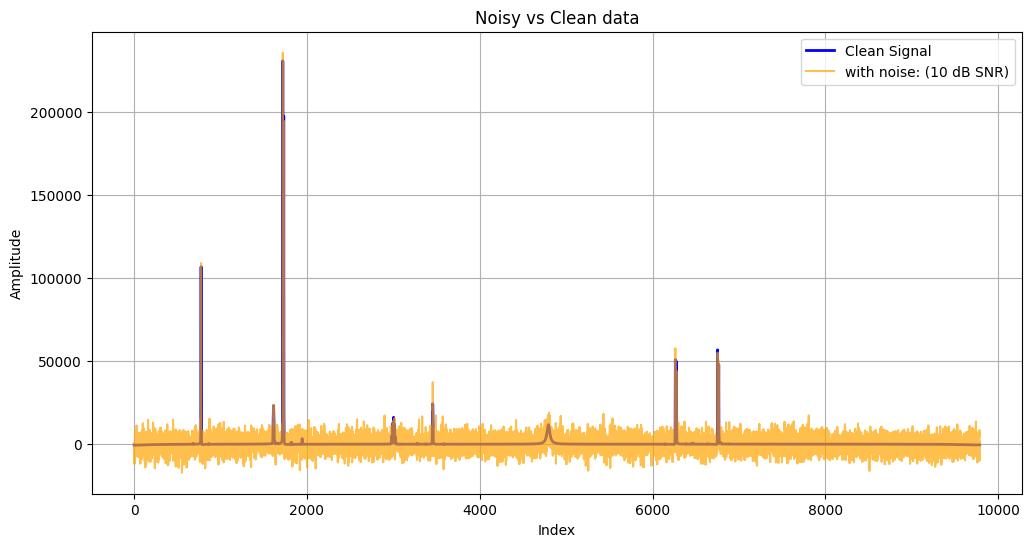

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(all_og_data[set_index], label="Clean Signal", color="blue", linewidth=2)
plt.plot(all_noisy[set_index], label=f"with noise: ({snr} dB SNR)", color="orange", alpha=0.7)

# convert to ppm later, rn just shows the index
plt.xlabel('Index')
plt.ylabel('Amplitude')
plt.title('Noisy vs Clean data')
plt.legend()
plt.grid(True)
plt.show()

Compare denoising capabilities across models and algorithms

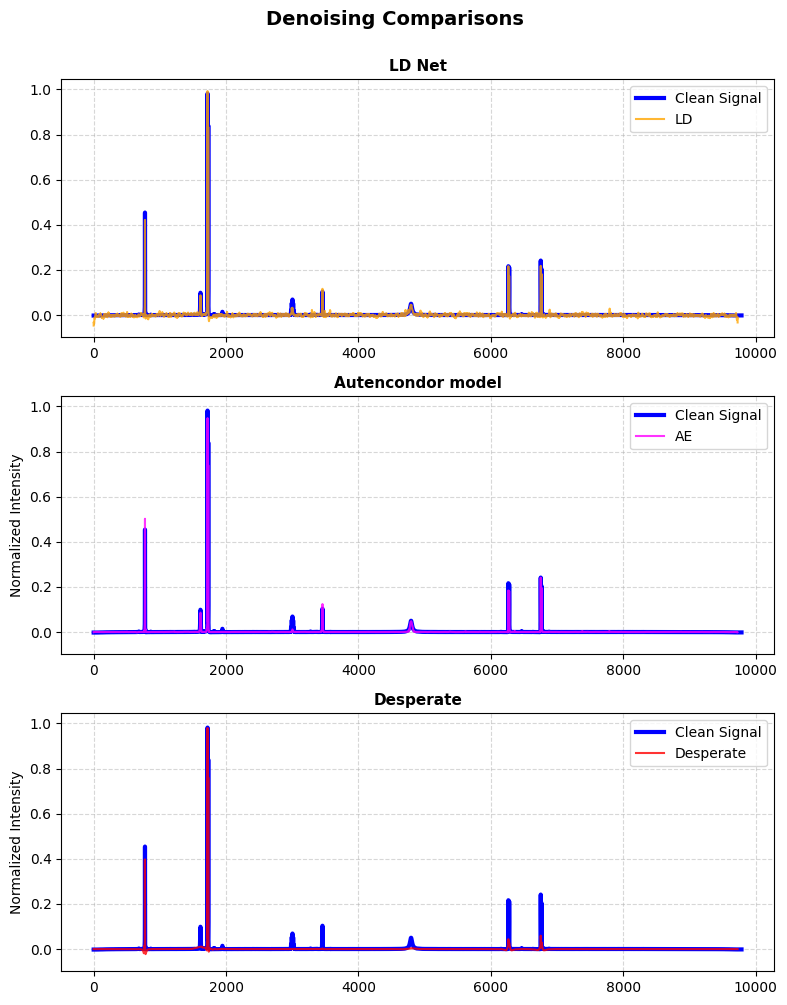

In [10]:
clean_sig = normalize_data(all_og_data[set_index], all_og_data[set_index])
ld_sig    = normalize_data(all_ld[set_index], all_og_data[set_index])
ae_sig    = normalize_data(all_ae[set_index], all_og_data[set_index])
desp_sig  = normalize_data(all_desperate[set_index], all_og_data[set_index])

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharey=True)

axes[0].plot(clean_sig, label="Clean Signal", color="blue", linewidth=3)
axes[0].plot(ld_sig, label="LD", color="orange", linewidth=1.5, alpha=0.8)
axes[0].set_title("LD Net", fontsize=11, fontweight='bold')
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(clean_sig, label="Clean Signal", color="blue", linewidth=3)
axes[1].plot(ae_sig, label="AE", color="magenta", linewidth=1.5, alpha=0.8)
axes[1].set_title("Autencondor model", fontsize=11, fontweight='bold')
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_ylabel("Normalized Intensity")

axes[2].plot(clean_sig, label="Clean Signal", color="blue", linewidth=3)
axes[2].plot(desp_sig, label="Desperate", color="red", linewidth=1.5, alpha=0.8)
axes[2].set_title("Desperate", fontsize=11, fontweight='bold')
axes[2].legend(loc="upper right")
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_ylabel("Normalized Intensity")

plt.suptitle(f"Denoising Comparisons", fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

In [11]:
print(f' Total sample size of inoragnic 1H (N): {len(all_snr_noisy)} compounds')

print(f' mean snr of model AE for average denoised sample: {np.mean(all_snr_ae)}')
print(f'std snr of model AE for average denoised sample: {np.std(all_snr_ae)}')

print(f' mean snr of model LD for average denoised sample: {np.mean(all_snr_ld)}')
print(f'std snr of model LD for average denoised sample: {np.std(all_snr_ld)}')

print(f' mean snr of model Desperate for average denoised sample: {np.mean(all_snr_desperate)}')
print(f'std snr of model Desperate for average denoised sample: {np.std(all_snr_desperate)}')

print(f' mean snr of model noisy data for average noisy sample: {np.mean(all_snr_noisy)}')
print(f'std snr of model noisy data for average noisy sample: {np.std(all_snr_noisy)}')

 Total sample size of inoragnic 1H (N): 25 compounds
 mean snr of model AE for average denoised sample: 3532.9150390625
std snr of model AE for average denoised sample: 1414.781005859375
 mean snr of model LD for average denoised sample: 164.48690795898438
std snr of model LD for average denoised sample: 46.43556213378906
 mean snr of model Desperate for average denoised sample: 5381.271577647639
std snr of model Desperate for average denoised sample: 9574.624328943986
 mean snr of model noisy data for average noisy sample: 47.72105305881577
std snr of model noisy data for average noisy sample: 3.640158416991936
